In [1]:
using LinearAlgebra
using QuantumToolbox
using CairoMakie

In [164]:
const Sub_divisions = 64
const iterations = 1024
const iter = 400
const tolerance = 0.998
const step_size = 5

initial_state = ComplexF64[1;0]
H_Gate = ComplexF64[1/√2 1/√2; 1/√2 -1/√2]
T_gate = ComplexF64[1 0; 0 exp(im*π/Sub_divisions)]

function apply_gate(state, gate)
    return gate * state
end

function rotate(state, i)
    return T_gate ^ i * state
end

function measure(vec)
    if abs2(vec[1]) > rand()
        vec[1] = 1
        vec[2] = 0
        return 0
        end
    vec[1] = 0
    vec[2] = 1
    return 1
end

function ramsey(state, gate, t)
    prep = apply_gate(state, gate)
    spinning = rotate(prep, t)
    final = apply_gate(spinning, gate)
    return measure(final)
end

function count(n, state, gate, t)
    count = 0
    for i in range(1,n)
        measured = ramsey(state, gate, t)
        if measured < 1
            count += 1
        end
    end
    return count
end

function operate(iter)
    t_range = range(1, iter)
    data = []
    for i in t_range
        push!(data, count(iterations, initial_state, H_Gate, i))
    end
    return data
end


function convert_to_prob(lst)
    prob = []
    for i in range(1,length(lst))
        push!(prob, lst[i]/iterations)
    end
    return prob
end

convert_to_prob (generic function with 1 method)

In [ ]:
ω_01 = 6.063 * 1000 #MHz
ω_pulse = 6.06 * 1000 #MHz
Δf = ω_01 - ω_pulse
precession_time = 1/Δf * 1000
#precession_time is 333 nanoseconds

function convert_time(lst)
    conv = []
    for i in lst
        push!(conv, i * precession_time/64 )
    end
    return conv
end

333.3333333333333

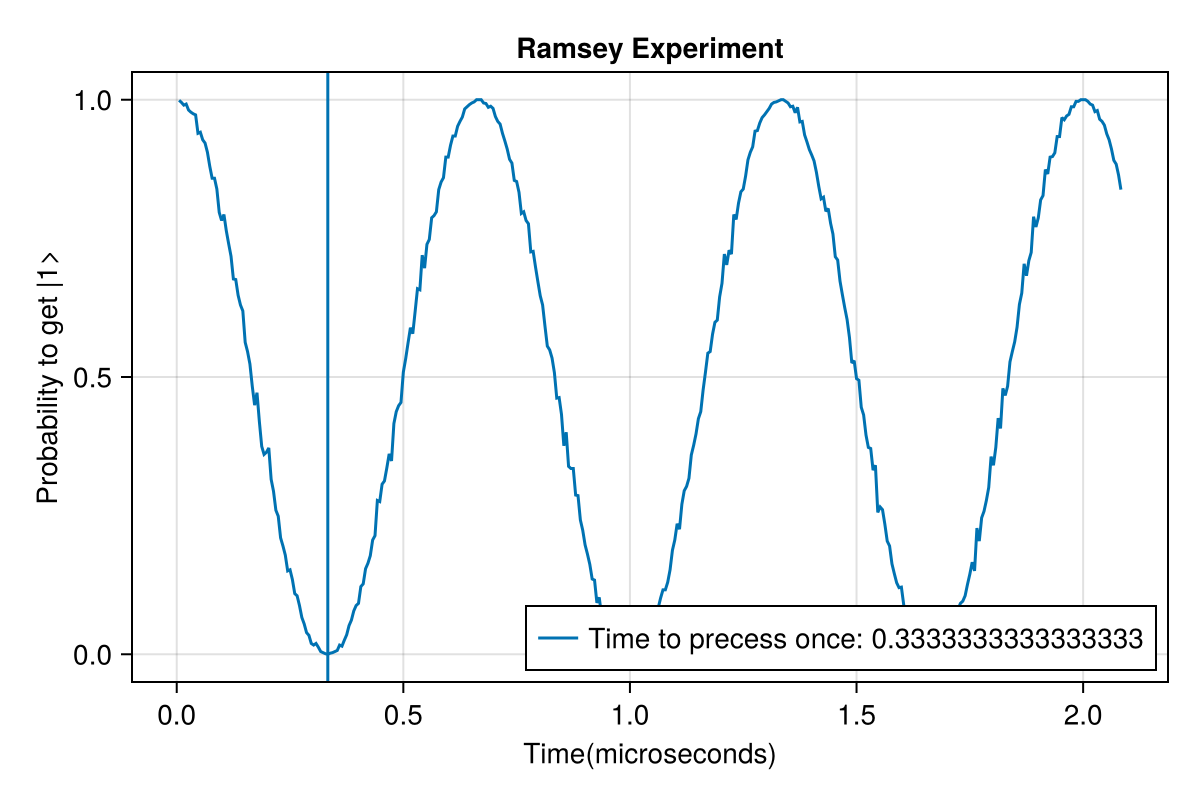

Any[0.005208333333333333, 0.65625, 1.3333333333333333, 1.984375, 2.0104166666666665]
Any[Any[96.25, 85.0, 63.75, 96.25, 96.25, 85.0, 77.0, 96.25, 77.0, 96.25], 96.25, 86.9]


In [288]:
n = 400
probs = convert_to_prob(operate(n))
t_range = range(1, n)
Ts = convert_time(t_range / 1000)

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, probs)
vlines!(ax, precession_time/1000, label = "Time to precess once: $(precession_time/1000)")
axislegend(ax; position = :rb)
display(fig)

println(find_time_periods(n, tol)[2])
println(calc_multi_period(n, tolerance))

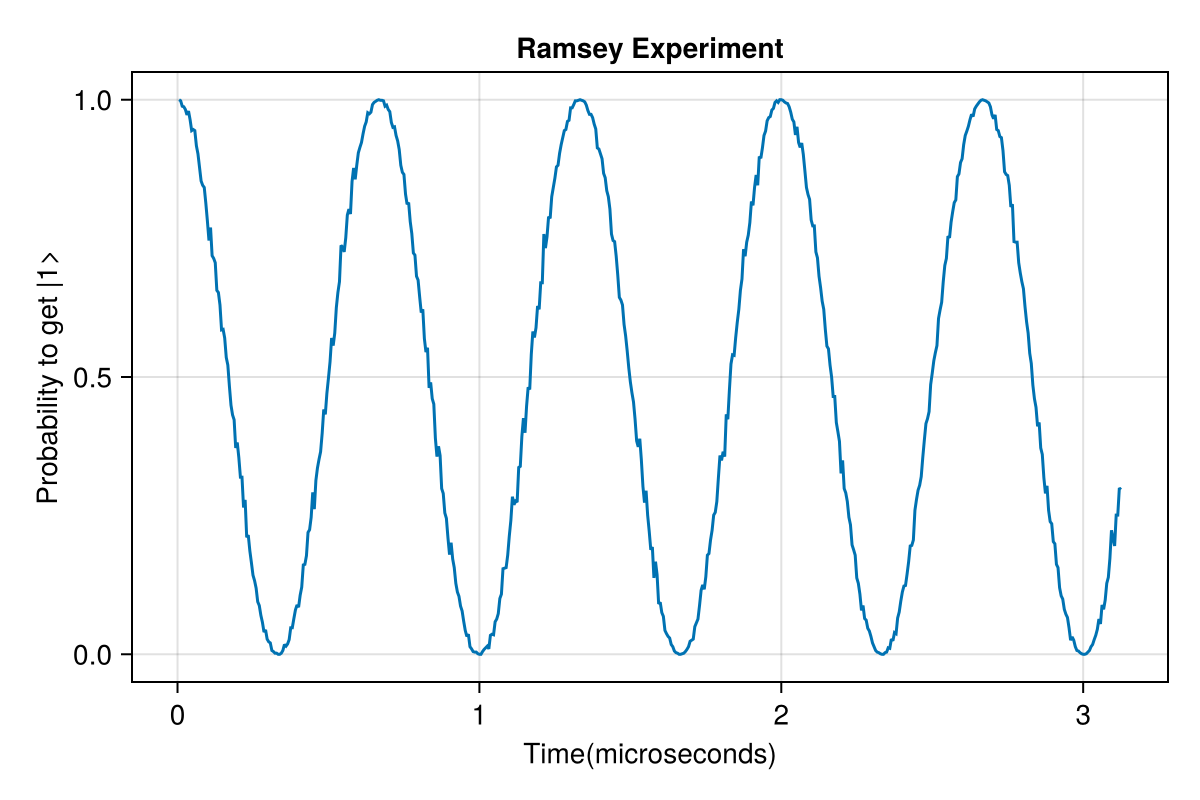

Any[0.005208333333333333, 0.65625, 0.6822916666666666, 1.3333333333333333, 1.984375, 2.0104166666666665, 2.661458333333333]
Any[Any[170.0, 127.5, 127.5, 127.5, 127.5, 127.5, 127.5, 127.5, 77.0, 102.0], 170.0, 124.15]


In [289]:
n = 600
probs = convert_to_prob(operate(n))
t_range = range(1, n)

Ts = convert_time(t_range / 1000)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, probs)
display(fig)

println(find_time_periods(n, tol)[2])
println(calc_multi_period(n, tolerance))

In [275]:
function calculate_ramsey_period(lst, tol)
    period = []
    if lst[1]>tol
        push!(period, 1)
    end
    for i in range(1,length(lst); step = 5)
        if i > 5  && i < length(lst) - (5+1)
            if lst[i]>tol
                push!(period, i)
            end
        end
    end

    return [period, (period[length(period)] - period[1])/length(period)]
end


function calc_multi_period(time, tol)
    periods = []
    for i in range(1,10)
        push!(periods, calculate_ramsey_period(convert_to_prob(operate(time)), tolerance)[2])
    end
    return [periods, maximum(periods), sum(periods)/length(periods)]
end

function convert_to_freq(time, tol)
    return 1/(calc_multi_period(time, tol)[3])
end

function find_time_periods(iters, tol)
    time_period = []
    for i in range(1, 10)
        probs = convert_to_prob(operate(iters))
        push!(time_period, convert_time(calculate_ramsey_period(probs, tolerance)[1])/1000)
    end
    time_lst_shrunk = []
    for i in range(1,10)
        for j in range(1,length(time_period[i]))
            if time_period[i][j] ∉ time_lst_shrunk
                push!(time_lst_shrunk, time_period[i][j])
            end
        end
    end
    sort!(time_lst_shrunk)
    return [time_period, time_lst_shrunk]
end

function calc_time_period(iters, tol)
    times =  find_time_periods(iters, tol)[2]
    return [times, (times[end] - times[1])/length(times), sum(times)/length(times)]
end

function convert_time_to_freq(iters, tol)
    return 1/calc_time_period(iters, tol)[2]
end

convert_time_to_freq (generic function with 1 method)

In [264]:
iter_2 = 6000
t_range = range(1, iter_2)
Ts = convert_time(t_range / 1000)
Δ = convert_to_freq(iter_2, tolerance) * 1000


6.685426598901683

In [292]:
iter_2 = 6000
t_range = range(1, iter_2)
Ts = convert_time(t_range / 1000)

A = 0.5
C = 0.5
T1 = 15 * 1000 #Microseconds(1000x nanoseconds)
Tϕ = 10^3 * 1000 #Microseconds(1000x nanoseconds)
T2x = (1/2T1 + 1/Tϕ)^-1/1000

function P(t, A, C)
    return A * exp(-t/T2x) * cos(2π* Δ * t) + C
end
decaying = []
border = []
for i in Ts
    push!(decaying, P(i, A, C))
    push!(border, A * exp(-i/T2x) + C)
end


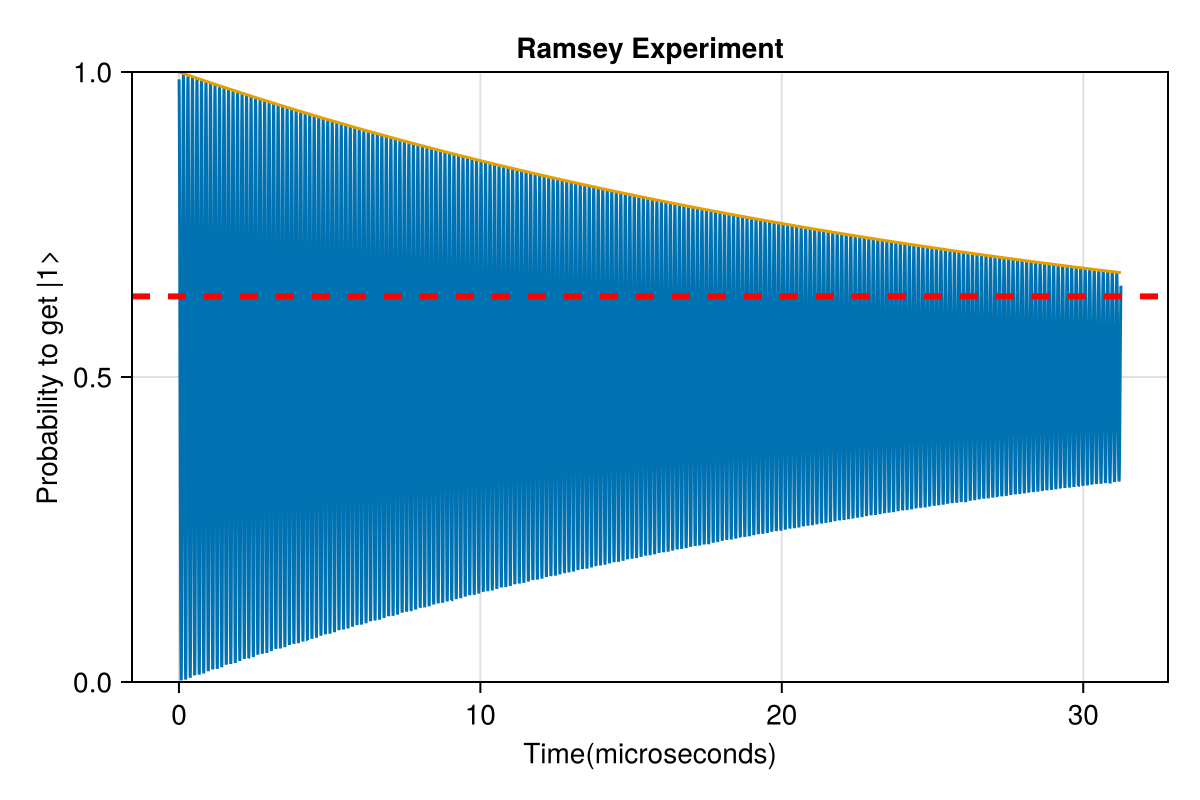

CairoMakie.Screen{IMAGE}


In [302]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Ramsey Experiment", xlabel = "Time(microseconds)", ylabel = "Probability to get |1>")
lines!(ax, Ts, decaying)
lines!(ax, Ts, border)
hlines!(ax, 1-1/ℯ, linewidth = 3, color = :red, linestyle = :dash)
CairoMakie.ylims!(ax, (0.0, 1.0))
display(fig)

In [304]:
save("Ramsey_expirement_w_decay.png", fig)